# Project Overheat: Predictive Maintenance AI
**AeroLogistics – Capstone Project**

**Goal:** predict a drive-motor failure **24 hours in advance** from IoT sensor telemetry, so the maintenance crew can act *before* a $50,000/minute warehouse shutdown.

**Pipeline**
1. Feature Engineering – 12-hour rolling windows
2. Target Shifting – 24-hour lead time
3. Chronological Train/Test Partition – no shuffling, no leakage
4. Modeling & Explainability – balanced Random Forest + feature importances

## Setup
Installs any missing library into the notebook's own Python environment (does nothing if everything is already installed).

In [23]:
import importlib, subprocess, sys

for pip_name, module in [("pandas", "pandas"), ("numpy", "numpy"),
                         ("matplotlib", "matplotlib"), ("scikit-learn", "sklearn")]:
    try:
        importlib.import_module(module)
    except ImportError:
        print(f"Installing {pip_name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])
importlib.invalidate_caches()
print("All required libraries are available.")

All required libraries are available.


In [24]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (classification_report, confusion_matrix,
                             recall_score, precision_score)

pd.set_option("display.width", 120)
RANDOM_STATE = 42

## Load the data
The loader tolerates small naming differences in the file name and column headers (spaces vs. underscores, capitalisation).

In [25]:
# --- locate the CSV (works locally, in Colab, Kaggle, or a sub-folder) ---------
import glob

def find_csv():
    roots = [".", "..", "data", "/content", "/content/drive/MyDrive", "/kaggle/input",
             "/mnt/data", "/mnt/user-data/uploads", os.path.expanduser("~/Downloads")]
    for pattern in ("*telemetry*.csv", "**/*telemetry*.csv"):
        for root in roots:
            hits = sorted(glob.glob(os.path.join(root, pattern), recursive=True))
            if hits:
                return hits[0]
    csvs = sorted(glob.glob("*.csv"))            # last resort: the only CSV in this folder
    return csvs[0] if len(csvs) == 1 else None

csv_path = find_csv()
if csv_path is None:
    try:                                          # Google Colab: ask for an upload
        from google.colab import files
        csv_path = next(iter(files.upload()))
    except ImportError:
        pass
if csv_path is None:
    raise FileNotFoundError("Put the telemetry CSV (e.g. iot_sensor_telemetry.csv) in the same folder "
                            "as this notebook, then run again. Current folder: " + os.getcwd())
print("Using data file:", csv_path)

df = pd.read_csv(csv_path)

# --- map columns to canonical names ------------------------------------------
def norm(c):
    return re.sub(r"[^a-z0-9]", "", str(c).lower())

def find_col(keys):
    for c in df.columns:
        n = norm(c)
        if all(k in n for k in keys):
            return c
    raise KeyError(f"No column containing {keys} in {list(df.columns)}")

rename = {
    find_col(["time"]):            "Timestamp",
    find_col(["temp"]):            "Sensor_Temp_C",
    find_col(["vib"]):             "Sensor_Vibration_mm",
    find_col(["volt"]):            "Sensor_Voltage_V",
    find_col(["fail"]):            "Catastrophic_Failure",
}
df = df.rename(columns=rename)
df["Catastrophic_Failure"] = (df["Catastrophic_Failure"].astype(str).str.strip().str.lower()
                              .isin(["1", "1.0", "true", "yes"])).astype(int)   # Boolean -> 0/1

print("Shape:", df.shape)
df.head()

Using data file: ..\OneDrive\Desktop\iot_sensor_telemetry.csv
Shape: (10000, 5)


,Timestamp,Sensor_Temp_C,Sensor_Vibration_mm,Sensor_Voltage_V,Catastrophic_Failure
0,2023-01-01 00:00:00,66.490142,1.064301,220.696572,0
1,2023-01-01 01:00:00,64.585207,1.138900,220.566647,0
2,2023-01-01 02:00:00,66.943066,1.080524,218.126960,0
3,2023-01-01 03:00:00,69.569090,1.222084,221.159168,0
4,2023-01-01 04:00:00,64.297540,1.439436,217.019835,0


In [26]:
print(df.dtypes, "\n")
print(df.isna().sum(), "\n")
print("Failure rate: {:.3%}  ({} failure hours out of {})".format(
    df["Catastrophic_Failure"].mean(), df["Catastrophic_Failure"].sum(), len(df)))

Timestamp                   str
Sensor_Temp_C           float64
Sensor_Vibration_mm     float64
Sensor_Voltage_V        float64
Catastrophic_Failure      int64
dtype: object 

Timestamp               0
Sensor_Temp_C           0
Sensor_Vibration_mm     0
Sensor_Voltage_V        0
Catastrophic_Failure    0
dtype: int64 

Failure rate: 0.150%  (15 failure hours out of 10000)


## Phase 1 – Feature Engineering (Rolling Windows)
A single mechanical jolt is noise; *sustained* shaking is degradation. We therefore build multi-hour rolling features:

* **12-hour rolling mean of temperature** (required) – captures sustained heating.
* **12-hour rolling standard deviation of vibration** (required) – captures erratic shaking.
* **Extra symmetric features** – rolling mean *and* standard deviation for all three sensors, so temperature, vibration and voltage compete on equal footing in the explainability phase.

Rolling windows only look **backward** (the window ends at the current row), so they never use future information.

In [27]:
# 1) parse timestamp & sort chronologically
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df = df.sort_values("Timestamp").reset_index(drop=True)
assert df["Timestamp"].is_monotonic_increasing

WINDOW = 12  # hours (one row = one hour)

# 2) rolling features (min_periods=WINDOW -> a full 12-hour window is required)
sensors = {"Temp": "Sensor_Temp_C", "Vibration": "Sensor_Vibration_mm", "Voltage": "Sensor_Voltage_V"}
for short, col in sensors.items():
    roll = df[col].rolling(window=WINDOW, min_periods=WINDOW)
    df[f"{short}_Rolling_Mean_12h"] = roll.mean()
    df[f"{short}_Rolling_Std_12h"]  = roll.std()

# 3) drop the initial NaN rows created by the rolling calculations
rolling_cols = [c for c in df.columns if "_Rolling_" in c]
n_before = len(df)
df = df.dropna(subset=rolling_cols).reset_index(drop=True)
print(f"Dropped {n_before - len(df)} initial NaN rows  ->  {len(df)} rows remain")
df[["Timestamp"] + rolling_cols].head()

Dropped 11 initial NaN rows  ->  9989 rows remain


,Timestamp,Temp_Rolling_Mean_12h,Temp_Rolling_Std_12h,Vibration_Rolling_Mean_12h,Vibration_Rolling_Std_12h,Voltage_Rolling_Mean_12h,Voltage_Rolling_Std_12h
0,2023-01-01 11:00:00,65.887866,2.232723,1.215311,0.164662,220.146055,2.413527
1,2023-01-01 12:00:00,65.824178,2.224868,1.204689,0.178793,219.990302,2.434983
2,2023-01-01 13:00:00,65.380424,2.917637,1.202015,0.180102,219.768690,2.497961
3,2023-01-01 14:00:00,64.787272,3.272959,1.225688,0.181347,220.011939,2.465470
4,2023-01-01 15:00:00,64.265943,2.921407,1.224540,0.181415,219.903422,2.438900


## Phase 2 – Target Shifting (24-hour lead time)
If we trained on the raw failure flag the model would only say *"the machine is breaking right now."*  
`shift(-24)` moves the label **up by 24 rows**, so the features at hour *t* are paired with "does a failure occur at hour *t + 24*?".

In [28]:
df["Failure_In_24_Hours"] = df["Catastrophic_Failure"].shift(-24)

# the last 24 rows have no future label -> drop them
df = df.iloc[:-24].copy()
assert df["Failure_In_24_Hours"].notna().all()
df["Failure_In_24_Hours"] = df["Failure_In_24_Hours"].astype(int)

# drop the original failure column to prevent target leakage
df = df.drop(columns=["Catastrophic_Failure"])

print("Rows after shifting:", len(df))
print("Target balance:\n", df["Failure_In_24_Hours"].value_counts())

Rows after shifting: 9965
Target balance:
 Failure_In_24_Hours
0    9950
1      15
Name: count, dtype: int64


## Phase 3 – Chronological Train/Test Partition
Random shuffling would let the model learn from the future to predict the past. We instead slice by time: **first 80 % → train, final 20 % → test**.

In [29]:
raw_cols = ["Sensor_Temp_C", "Sensor_Vibration_mm", "Sensor_Voltage_V"]
feature_cols = raw_cols + rolling_cols

X = df[feature_cols]
y = df["Failure_In_24_Hours"]

split_idx = int(len(df) * 0.80)          # manual slice, NO shuffling
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train: {len(X_train)} rows  ({df['Timestamp'].iloc[0]}  ->  {df['Timestamp'].iloc[split_idx-1]})")
print(f"Test : {len(X_test)} rows  ({df['Timestamp'].iloc[split_idx]}  ->  {df['Timestamp'].iloc[-1]})")
assert df["Timestamp"].iloc[split_idx-1] < df["Timestamp"].iloc[split_idx]   # no time overlap
print("Failures in train:", int(y_train.sum()), "| Failures in test:", int(y_test.sum()))

Train: 7972 rows  (2023-01-01 11:00:00  ->  2023-11-29 14:00:00)
Test : 1993 rows  (2023-11-29 15:00:00  ->  2024-02-20 15:00:00)
Failures in train: 12 | Failures in test: 3


## Phase 4 – Modeling & Explainability
A **Random Forest** with `class_weight="balanced_subsample"` penalises the model heavily for missing rare failure events.

Missing a failure is far more expensive than a false alarm, so we tune the **decision threshold** for recall. The threshold is chosen with an **expanding-window time-series cross-validation inside the training period only** – the test set is never touched for tuning.

Rule: pick the highest threshold whose out-of-fold recall is at least **75 %** (the fewest false alarms for that recall level).

In [30]:
def make_rf():
    return RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=3,
        class_weight="balanced_subsample",   # penalise missed failures
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

# --- choose a recall-oriented threshold with time-series CV (training data only) --
TARGET_RECALL = 0.75
oof = np.full(len(X_train), np.nan)
for tr_idx, va_idx in TimeSeriesSplit(n_splits=5).split(X_train):
    if y_train.iloc[tr_idx].sum() == 0:
        continue
    m = make_rf().fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
    oof[va_idx] = m.predict_proba(X_train.iloc[va_idx])[:, 1]
mask = ~np.isnan(oof)

grid = np.round(np.arange(0.05, 0.55, 0.05), 2)
threshold = 0.5   # default if there is not enough history to tune
if y_train[mask].sum() > 0:
    rec = [recall_score(y_train[mask], (oof[mask] >= t).astype(int), zero_division=0) for t in grid]
    ok = [t for t, r in zip(grid, rec) if r >= TARGET_RECALL]
    threshold = float(max(ok)) if ok else float(grid[int(np.argmax(rec))])
print(f"Selected decision threshold: {threshold:.2f}  (out-of-fold recall target {TARGET_RECALL:.0%})")

# --- final model: fit on the FULL training period ------------------------------
rf = make_rf().fit(X_train, y_train)
proba_test = rf.predict_proba(X_test)[:, 1]
y_pred = (proba_test >= threshold).astype(int)

Selected decision threshold: 0.10  (out-of-fold recall target 75%)


In [31]:
print("=== Test-set performance (final 20 % of the timeline) ===")
print(classification_report(y_test, y_pred, target_names=["Normal", "Failure in 24h"], zero_division=0))

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
print("Confusion matrix  [rows = actual, cols = predicted]")
print(pd.DataFrame(cm, index=["Actual Normal", "Actual Failure"], columns=["Pred Normal", "Pred Failure"]))

print(f"\nFailure-class RECALL   : {recall_score(y_test, y_pred, zero_division=0):.3f}")
print(f"Failure-class PRECISION: {precision_score(y_test, y_pred, zero_division=0):.3f}")

=== Test-set performance (final 20 % of the timeline) ===
                precision    recall  f1-score   support

        Normal       1.00      1.00      1.00      1990
Failure in 24h       0.20      0.67      0.31         3

      accuracy                           1.00      1993
     macro avg       0.60      0.83      0.65      1993
  weighted avg       1.00      1.00      1.00      1993

Confusion matrix  [rows = actual, cols = predicted]
                Pred Normal  Pred Failure
Actual Normal          1982             8
Actual Failure            1             2

Failure-class RECALL   : 0.667
Failure-class PRECISION: 0.200


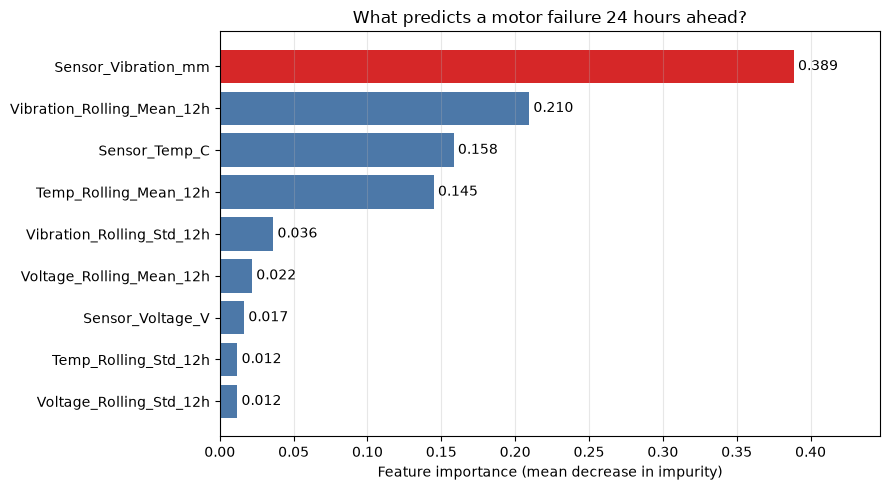

Sensor_Vibration_mm           0.3887
Vibration_Rolling_Mean_12h    0.2095
Sensor_Temp_C                 0.1584
Temp_Rolling_Mean_12h         0.1449
Vibration_Rolling_Std_12h     0.0363
Voltage_Rolling_Mean_12h      0.0219
Sensor_Voltage_V              0.0165
Temp_Rolling_Std_12h          0.0120
Voltage_Rolling_Std_12h       0.0119


In [32]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#d62728" if i == importances.idxmax() else "#4c78a8" for i in importances.index]
bars = ax.barh(importances.index, importances.values, color=colors)
ax.bar_label(bars, fmt="%.3f", padding=3)
ax.set_xlabel("Feature importance (mean decrease in impurity)")
ax.set_title("What predicts a motor failure 24 hours ahead?")
ax.set_xlim(0, importances.max() * 1.15)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print(importances.sort_values(ascending=False).round(4).to_string())

### Business Recommendation for the Maintenance Crew
The text below is generated from the model's own results, so it always matches the chart above.

In [33]:
group_map = {
    "Temperature": [c for c in feature_cols if "Temp" in c],
    "Vibration":   [c for c in feature_cols if "Vibration" in c],
    "Voltage":     [c for c in feature_cols if "Voltage" in c],
}
group_imp = {g: float(importances[cols].sum()) for g, cols in group_map.items()}
ranked = sorted(group_imp.items(), key=lambda x: -x[1])
lead, runner_up = ranked[0][0], ranked[1][0]
near_tie = (ranked[0][1] - ranked[1][1]) < 0.05
top_feature = importances.idxmax()

actions = {
    "Temperature": "alert on the 12-hour average motor temperature and inspect cooling/bearings when it leaves its normal band",
    "Vibration":   "alert on vibration level and its 12-hour variability, and check bearings/alignment when they rise above the normal band",
    "Voltage":     "alert on supply-voltage drift and inspect the power supply and motor windings",
}

rec_recall = recall_score(y_test, y_pred, zero_division=0)
n_fail_test = int(y_test.sum())
n_alerts = int(y_pred.sum())
caught = int(round(rec_recall * n_fail_test))

print("BUSINESS RECOMMENDATION")
print("-" * 60)
print("Sensor group importance: " + ", ".join(f"{g} {v:.1%}" for g, v in ranked))
if near_tie:
    print(f"\n1. Leading indicators: {lead.upper()} and {runner_up.upper()} are almost tied "
          f"(top single feature: {top_feature}). Monitor both together.")
    print(f"2. Action: {actions[lead]}; also {actions[runner_up]}.")
else:
    print(f"\n1. Leading indicator: {lead.upper()} (top single feature: {top_feature}).")
    print(f"2. Action: {actions[lead]}.")
print(f"3. On the held-out final 20% the model caught {caught} of {n_fail_test} failures ({rec_recall:.0%}) "
      f"24 hours ahead, using {n_alerts} alerts over {len(y_test)} hours. Failures are rare, so treat this "
      "as a small-sample estimate.")
if rec_recall >= 0.7:
    print("   At $50,000 per minute of downtime, one avoided shutdown outweighs many false-alarm "
          "inspections, so we deliberately favour recall over precision.")
else:
    print("   Keep routine inspections in place and consider a lower alert threshold "
          "(more false alarms, fewer missed failures) until more failure history is collected.")
print("4. Alert on SUSTAINED trends (12 hours or more), not on single spikes, to avoid alarm fatigue.")
print("5. Retrain monthly on fresh telemetry and re-check the ranking, since motor wear patterns can drift.")

BUSINESS RECOMMENDATION
------------------------------------------------------------
Sensor group importance: Vibration 63.4%, Temperature 31.5%, Voltage 5.0%

1. Leading indicator: VIBRATION (top single feature: Sensor_Vibration_mm).
2. Action: alert on vibration level and its 12-hour variability, and check bearings/alignment when they rise above the normal band.
3. On the held-out final 20% the model caught 2 of 3 failures (67%) 24 hours ahead, using 10 alerts over 1993 hours. Failures are rare, so treat this as a small-sample estimate.
   Keep routine inspections in place and consider a lower alert threshold (more false alarms, fewer missed failures) until more failure history is collected.
4. Alert on SUSTAINED trends (12 hours or more), not on single spikes, to avoid alarm fatigue.
5. Retrain monthly on fresh telemetry and re-check the ranking, since motor wear patterns can drift.
